# Import libraries

In [1]:
import pandas as pd 
import numpy as np
import joblib

from scipy.sparse import load_npz, hstack
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval

from model_utils import train_model, classify_analysis, error_analysis
from preprocessing_utils import add_shared_features, tokens_to_text

In [2]:
PROCESS_DATA_PATH = "preprocess_data"
MODEL_PATH = "models"
RANDOM_STATE = 42

DROP_COLUMNS = [
    "qid1",
    "qid2",
    "question1",
    "question2",
    "question1_tokens",
    "question2_tokens",
    "split",
    "question1_clean",
    "question2_clean",
    "is_duplicate"
]

EMBEDDING_FEATURES = [
    "embedding_cosine",
    "embedding_euclidean"
]

# TF-IDF

## With stopwords

### Data Loading

#### Data

In [3]:
train_df_sw = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_sw_tf_idf.parquet")
val_df_sw = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_sw_tf_idf.parquet")

train_df_sw.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[what, be, practical, management, and, what, b...","[what, be, the, practical, aspect, of, strateg...",5,0.555556,0.833333,1,7,what be practical management and what be strat...,what be the practical aspect of strategic mana...,0.500282
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[how, useful, be, makeuseof, answer]","[be, there, any, q, a, site, that, be, not, ya...",2,0.117647,0.400000,11,46,how useful be makeuseof answer,be there any q a site that be not yahoo answer...,0.060493
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,0.777778,2,9,which be the best place to reside in india and...,which ia the best place to visit in india,0.318665


#### TF-IDF

In [4]:
train_sw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/train_sw_tf_idf_q1_vec.npz")
train_sw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/train_sw_tf_idf_q2_vec.npz")

val_sw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/val_sw_tf_idf_q1_vec.npz")
val_sw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/val_sw_tf_idf_q2_vec.npz")

train_sw_q1_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4671378 stored elements and shape (261296, 215129)>

### Design matrix and target

In [5]:
X_train_sw = hstack([train_sw_q1_vec, train_sw_q2_vec])
X_val_sw = hstack([val_sw_q1_vec, val_sw_q2_vec])

X_train_sw

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9429335 stored elements and shape (261296, 430258)>

In [6]:
y_train_sw = train_df_sw['is_duplicate']
y_val_sw = val_df_sw['is_duplicate']

y_train_sw.head(3)

0    0
1    0
2    0
Name: is_duplicate, dtype: int64

### Basic Model

In [7]:
xgb_sw_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

In [8]:
train_model(xgb_sw_model, X_train_sw, y_train_sw)

Training time: 271.77 seconds


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 271.76685980008915)

#### Evaluation

Training
Log Loss      : 0.4884
ROC-AUC       : 0.8454
F1-score      : 0.6113
Inference time: 21.1233 s


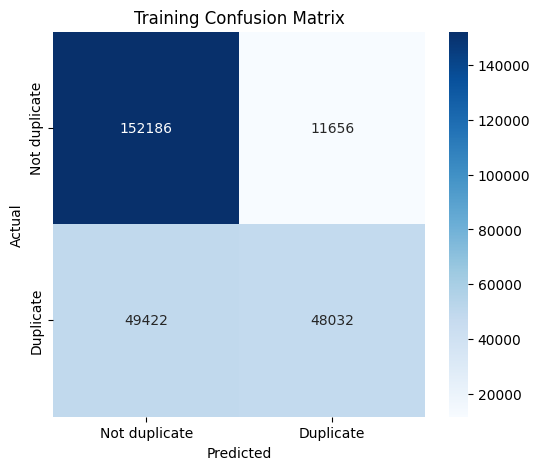


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.93      0.83    163842
           1       0.80      0.49      0.61     97454

    accuracy                           0.77    261296
   macro avg       0.78      0.71      0.72    261296
weighted avg       0.77      0.77      0.75    261296

Validation
Log Loss      : 0.5544
ROC-AUC       : 0.7655
F1-score      : 0.4396
Inference time: 5.7891 s


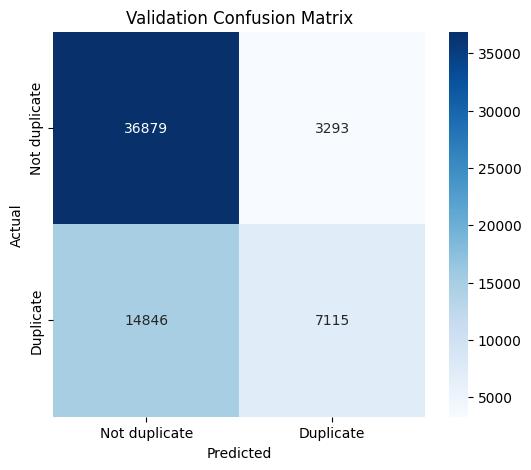


Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.92      0.80     40172
           1       0.68      0.32      0.44     21961

    accuracy                           0.71     62133
   macro avg       0.70      0.62      0.62     62133
weighted avg       0.70      0.71      0.67     62133



{'log_loss': 0.5543830347436871,
 'roc_auc': 0.7654738828220566,
 'f1_score': 0.4396181531712441,
 'inference_time': 5.78910709999036}

In [9]:
classify_analysis(y_train_sw, X_train_sw, xgb_sw_model, 'Training')
classify_analysis(y_val_sw, X_val_sw, xgb_sw_model, 'Validation')

#### Error analysis

In [49]:
train_errors_sw = error_analysis(train_df_sw, X_train_sw, xgb_sw_model)

print("False Positive training examples")
display(train_errors_sw["fp"].head())

print("False Negative training examples")
display(train_errors_sw["fn"].head())

Error Analysis
TP : 48032
TN : 152186
FP : 11656
FN : 49422
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,0.777778,2,9,which be the best place to reside in india and...,which ia the best place to visit in india,0.318665,1,0.689915
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,"[which, language, do, you, think, be, the, mos...","[which, be, the, most, difficult, language, of...",7,0.466667,0.700000,2,11,which language do you think be the most diffic...,which be the most difficult language of the wo...,0.402059,1,0.585531
47,258350,258351,Why is making money online is difficult?,Is making money online real?,0,train,"[why, be, make, money, online, be, difficult]","[be, make, money, online, real]",4,0.571429,0.800000,2,12,why be make money online be difficult,be make money online real,0.464251,1,0.609119
49,432554,432555,What is the best book to read on investment st...,What are some good books on investment?,0,train,"[what, be, the, best, book, to, read, on, inve...","[what, be, some, good, book, on, investment]",5,0.416667,0.714286,3,16,what be the best book to read on investment st...,what be some good book on investment,0.412511,1,0.549562
53,243093,261858,How can I get a six pack and how long would it...,How long would it take to get six packs?,0,train,"[how, can, i, get, a, six, pack, and, how, lon...","[how, long, would, it, take, to, get, six, pack]",8,0.615385,0.888889,4,12,how can i get a six pack and how long would it...,how long would it take to get six pack,0.807026,1,0.554273


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
7,176809,185587,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,1,train,"[what, be, the, best, small, business, to, sta...","[which, business, startup, should, i, start, i...",5,0.263158,0.500000,5,38,what be the best small business to start in na...,which business startup should i start in nagpu...,0.318206,0,0.454620
18,153297,153298,What percent of babies in the world are born w...,What percent of babies are born with a disabil...,1,train,"[what, percent, of, baby, in, the, world, be, ...","[what, percent, of, baby, be, bear, with, a, d...",9,0.750000,1.000000,3,13,what percent of baby in the world be bear with...,what percent of baby be bear with a disability,0.827874,0,0.239255
21,237270,144610,What is the evolutionary explanation for the e...,What's the evolutionary reason for the hymen?,1,train,"[what, be, the, evolutionary, explanation, for...","[what, be, the, evolutionary, reason, for, the...",6,0.600000,0.857143,3,23,what be the evolutionary explanation for the e...,what be the evolutionary reason for the hymen,0.577135,0,0.413240
27,370532,91966,What reasons would there be for Christopher Co...,Why was Christopher Columbus considered a vill...,1,train,"[what, reason, would, there, be, for, christop...","[why, be, christopher, columbus, consider, a, ...",6,0.500000,0.857143,5,27,what reason would there be for christopher col...,why be christopher columbus consider a villain,0.511012,0,0.253699
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,"[what, be, the, prerequisite, for, study, fini...","[what, be, the, mathematical, prerequisite, fo...",8,0.615385,0.800000,2,5,what be the prerequisite for study finite elem...,what be the mathematical prerequisite for unde...,0.559957,0,0.228752


In [50]:
val_errors_sw = error_analysis(val_df_sw, X_val_sw, xgb_sw_model)

print("False Positive validation examples")
display(val_errors_sw["fp"].head())

print("False Negative validation examples")
display(val_errors_sw["fn"].head())

Error Analysis
TP : 7115
TN : 36879
FP : 3293
FN : 14846
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[when, do, you, join, quora]","[why, do, i, join, quora]",3,0.428571,0.600000,0,3,when do you join quora,why do i join quora,0.547603,1,0.579334
74,187388,361472,Who has the most beautiful natural boobs you'v...,Which is the most beautiful not so famous actr...,0,val,"[who, have, the, most, beautiful, natural, boo...","[which, be, the, most, beautiful, not, so, fam...",7,0.437500,0.700000,2,11,who have the most beautiful natural boob you h...,which be the most beautiful not so famous actr...,0.494036,1,0.502423
76,167340,2962,How do I know if a girl is in love with me?,How can I tell if my girlfriend really loves me?,0,val,"[how, do, i, know, if, a, girl, be, in, love, ...","[how, can, i, tell, if, my, girlfriend, really...",5,0.294118,0.500000,2,5,how do i know if a girl be in love with me,how can i tell if my girlfriend really love me,0.109344,1,0.585061
81,229859,229860,What do you think of the hacker group Anonymous?,How do I become part of the hacker group Anony...,0,val,"[what, do, you, think, of, the, hacker, group,...","[how, do, i, become, part, of, the, hacker, gr...",6,0.461538,0.666667,1,3,what do you think of the hacker group anonymous,how do i become part of the hacker group anony...,0.697287,1,0.595728
97,167896,167897,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0,val,"[why, do, obama, always, call, donald, trump, ...","[why, be, donald, trump, call, the, donald]",5,0.555556,0.833333,2,13,why do obama always call donald trump the donald,why be donald trump call the donald,0.472791,1,0.582601


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,"[how, can, i, open, a, ppf, account, and, what...","[what, be, ppf, account]",4,0.333333,1.000000,8,36,how can i open a ppf account and what be it be...,what be ppf account,0.559547,0,0.311113
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"[what, be, the, sahara, and, how, do, the, ave...","[what, be, the, sahara, and, how, do, the, ave...",14,0.823529,0.933333,1,3,what be the sahara and how do the average temp...,what be the sahara and how do the average temp...,0.753968,0,0.175480
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,"[when, be, it, too, late, to, learn, piano]","[be, it, too, late, to, learn, to, play, the, ...",7,0.583333,0.875000,4,13,when be it too late to learn piano,be it too late to learn to play the piano at 26,0.601009,0,0.330996
9,220341,22484,Which books are best for each subject while pr...,What are the best books for UGC NET commerce?,1,val,"[which, book, be, best, for, each, subject, wh...","[what, be, the, best, book, for, ugc, net, com...",7,0.500000,0.777778,4,30,which book be best for each subject while prep...,what be the best book for ugc net commerce,0.616794,0,0.360673
10,356289,356290,What is a submersible pump? What purpose does ...,What is a submersible pump?,1,val,"[what, be, a, submersible, pump, what, purpose...","[what, be, a, submersible, pump]",5,0.555556,1.000000,5,28,what be a submersible pump what purpose do it ...,what be a submersible pump,0.431921,0,0.381145


## Without stopwords

### Data Loading

#### Data

In [10]:
train_df_nosw = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_nosw_tf_idf.parquet")
val_df_nosw = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_nosw_tf_idf.parquet")

train_df_nosw.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[practical, management, strategic, management]","[practical, aspect, strategic, management]",3,0.750000,1.000000,0,7,practical management strategic management,practical aspect strategic management,0.878978
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[useful, makeuseof, answer]","[q, site, yahoo, answer, hate, speech, allow]",1,0.111111,0.333333,4,46,useful makeuseof answer,q site yahoo answer hate speech allow,0.128030
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500000,0.750000,1,9,best place reside india,ia best place visit india,0.225184


#### TF-IDF

In [11]:
train_nosw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/train_nosw_tf_idf_q1_vec.npz")
train_nosw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/train_nosw_tf_idf_q2_vec.npz")

val_nosw_q1_vec = load_npz(f"{PROCESS_DATA_PATH}/val_nosw_tf_idf_q1_vec.npz")
val_nosw_q2_vec = load_npz(f"{PROCESS_DATA_PATH}/val_nosw_tf_idf_q2_vec.npz")

train_nosw_q1_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2112912 stored elements and shape (261296, 172154)>

### Design matrix and target

In [12]:
X_train_nosw = hstack([train_nosw_q1_vec, train_nosw_q2_vec])
X_val_nosw = hstack([val_nosw_q1_vec, val_nosw_q2_vec])

X_train_nosw

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4252270 stored elements and shape (261296, 344308)>

In [13]:
y_train_nosw = train_df_nosw['is_duplicate']
y_val_nosw = val_df_nosw['is_duplicate']

y_train_nosw.head(3)

0    0
1    0
2    0
Name: is_duplicate, dtype: int64

### Basic Model

In [14]:
xgb_nosw_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

In [15]:
train_model(xgb_nosw_model, X_train_nosw, y_train_nosw)

Training time: 159.45 seconds


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 159.44767999998294)

#### Evaluation

Training
Log Loss      : 0.5263
ROC-AUC       : 0.8123
F1-score      : 0.5333
Inference time: 16.9635 s


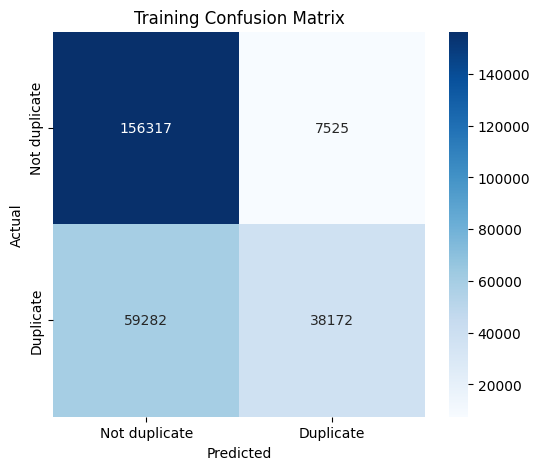


Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.95      0.82    163842
           1       0.84      0.39      0.53     97454

    accuracy                           0.74    261296
   macro avg       0.78      0.67      0.68    261296
weighted avg       0.77      0.74      0.72    261296

Validation
Log Loss      : 0.5865
ROC-AUC       : 0.7249
F1-score      : 0.3182
Inference time: 4.4214 s


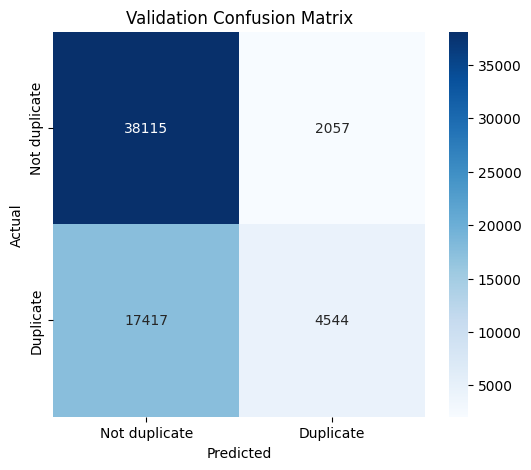


Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.95      0.80     40172
           1       0.69      0.21      0.32     21961

    accuracy                           0.69     62133
   macro avg       0.69      0.58      0.56     62133
weighted avg       0.69      0.69      0.63     62133



{'log_loss': 0.5864573041113104,
 'roc_auc': 0.7248944413118577,
 'f1_score': 0.31818500105034664,
 'inference_time': 4.421434000018053}

In [16]:
classify_analysis(y_train_nosw, X_train_nosw, xgb_nosw_model, 'Training')
classify_analysis(y_val_nosw, X_val_nosw, xgb_nosw_model, 'Validation')

#### Error analysis

In [51]:
train_errors_nosw = error_analysis(train_df_nosw, X_train_nosw, xgb_nosw_model)

print("False Positive training examples")
display(train_errors_nosw["fp"].head())

print("False Negative training examples")
display(train_errors_nosw["fn"].head())

Error Analysis
TP : 38172
TN : 156317
FP : 7525
FN : 59282
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500000,0.75,1,9,best place reside india,ia best place visit india,0.225184,1,0.577391
10,531572,531573,"If an answer has been collapsed, and then impr...",Why did Quora collapse my answer on ISIS and 911?,0,train,"[answer, collapse, improve, uncollapsed, colla...","[quora, collapse, answer, isi, 911]",3,0.333333,0.60,4,89,answer collapse improve uncollapsed collapse d...,quora collapse answer isi 911,0.314452,1,0.630828
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,"[language, think, difficult, world]","[difficult, language, world]",3,0.750000,1.00,1,11,language think difficult world,difficult language world,0.306066,1,0.545548
47,258350,258351,Why is making money online is difficult?,Is making money online real?,0,train,"[make, money, online, difficult]","[make, money, online, real]",3,0.600000,0.75,0,12,make money online difficult,make money online real,0.562742,1,0.776235
73,303067,15059,When did Quora introduce promoted by ads?,How do I advertise on Quora?,0,train,"[quora, introduce, promote, ad]","[advertise, quora]",1,0.200000,0.50,2,13,quora introduce promote ad,advertise quora,0.103600,1,0.630058


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
7,176809,185587,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,1,train,"[best, small, business, start, nagpur]","[business, startup, start, nagpur, best, chanc...",4,0.500000,0.800000,2,38,best small business start nagpur,business startup start nagpur best chance surv...,0.393637,0,0.454472
14,72076,54728,How should I write blog?,How do we write blogs?,1,train,"[write, blog]","[write, blog]",2,1.000000,1.000000,0,2,write blog,write blog,1.000000,0,0.322198
18,153297,153298,What percent of babies in the world are born w...,What percent of babies are born with a disabil...,1,train,"[percent, baby, world, bear, disability]","[percent, baby, bear, disability]",4,0.800000,1.000000,1,13,percent baby world bear disability,percent baby bear disability,0.856145,0,0.331490
21,237270,144610,What is the evolutionary explanation for the e...,What's the evolutionary reason for the hymen?,1,train,"[evolutionary, explanation, existence, hymen]","[evolutionary, reason, hymen]",2,0.400000,0.666667,1,23,evolutionary explanation existence hymen,evolutionary reason hymen,0.376743,0,0.343563
27,370532,91966,What reasons would there be for Christopher Co...,Why was Christopher Columbus considered a vill...,1,train,"[reason, would, christopher, columbus, conside...","[christopher, columbus, consider, villain]",4,0.666667,1.000000,2,27,reason would christopher columbus consider vil...,christopher columbus consider villain,0.892402,0,0.322198


In [52]:
val_errors_nosw = error_analysis(val_df_nosw, X_val_nosw, xgb_nosw_model)

print("False Positive validation examples")
display(val_errors_nosw["fp"].head())

print("False Negative validation examples")
display(val_errors_nosw["fn"].head())

Error Analysis
TP : 4544
TN : 38115
FP : 2057
FN : 17417
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[join, quora]","[join, quora]",2,1.000000,1.000000,0,3,join quora,join quora,1.000000,1,0.630058
65,81578,223898,How much does youtube pay per 1000 views?,Will YouTube pay $1 for 1000 views? Why am I n...,0,val,"[much, youtube, pay, per, 1000, view]","[youtube, pay, 1, 1000, view, get, revenue]",4,0.444444,0.666667,1,24,much youtube pay per 1000 view,youtube pay 1 1000 view get revenue,0.440755,1,0.551436
81,229859,229860,What do you think of the hacker group Anonymous?,How do I become part of the hacker group Anony...,0,val,"[think, hacker, group, anonymous]","[become, part, hacker, group, anonymous]",3,0.500000,0.750000,1,3,think hacker group anonymous,become part hacker group anonymous,0.769428,1,0.677051
97,167896,167897,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0,val,"[obama, always, call, donald, trump, donald]","[donald, trump, call, donald]",3,0.600000,1.000000,2,13,obama always call donald trump donald,donald trump call donald,0.606080,1,0.619592
165,510861,510862,What's the most interesting reason you've deci...,What do you think of your Quora followers?,0,val,"[interesting, reason, decide, follow, someone,...","[think, quora, follower]",1,0.125000,0.333333,3,35,interesting reason decide follow someone quora,think quora follower,0.055141,1,0.630058


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,common_ratio,len_diff_words,len_diff_chars,question1_clean,question2_clean,tfidf_cosine,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,"[open, ppf, account, benefit]","[ppf, account]",2,0.500000,1.000000,2,36,open ppf account benefit,ppf account,0.642243,0,0.330928
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"[sahara, average, temperatures, compare, one, ...","[sahara, average, temperatures, compare, one, ...",5,0.625000,0.833333,1,3,sahara average temperatures compare one antarc...,sahara average temperatures compare one gibson...,0.527260,0,0.140748
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,"[late, learn, piano]","[late, learn, play, piano, 26]",3,0.600000,1.000000,2,13,late learn piano,late learn play piano 26,0.590149,0,0.420805
7,33502,31173,How do I get my picture to be different on Quora?,How do I use my picture as my profile picture ...,1,val,"[get, picture, different, quora]","[use, picture, profile, picture, quora]",2,0.333333,0.500000,1,6,get picture different quora,use picture profile picture quora,0.236499,0,0.461406
9,220341,22484,Which books are best for each subject while pr...,What are the best books for UGC NET commerce?,1,val,"[book, best, subject, prepare, ugc, net, comme...","[best, book, ugc, net, commerce]",5,0.714286,1.000000,2,30,book best subject prepare ugc net commerce,best book ugc net commerce,0.577916,0,0.371530


# TF-IDF + SVD

## With stopwords

### Data Loading

In [17]:
train_df_sw_svd = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_sw_tf_idf_svd.parquet")
val_df_sw_svd = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_sw_tf_idf_svd.parquet")

train_df_sw_svd.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_90,q2_svd_91,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[what, be, practical, management, and, what, b...","[what, be, the, practical, aspect, of, strateg...",5,0.555556,...,0.002771,-0.000996,-0.000210,-0.011027,0.003078,-0.002213,-0.004684,0.000260,-0.008821,0.003365
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[how, useful, be, makeuseof, answer]","[be, there, any, q, a, site, that, be, not, ya...",2,0.117647,...,-0.000813,0.014216,-0.013116,-0.002396,0.022425,-0.016162,-0.015395,0.021079,0.012554,0.003694
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,...,-0.006432,0.017445,0.014441,0.086373,-0.045393,0.026737,0.024533,-0.005883,-0.012869,-0.015971


### Design matrix and target

In [18]:
X_train_sw_svd = train_df_sw_svd.drop(columns=DROP_COLUMNS)
X_val_sw_svd = val_df_sw_svd.drop(columns=DROP_COLUMNS)

X_train_sw_svd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261296 entries, 0 to 261295
Columns: 206 entries, common_word_count to q2_svd_99
dtypes: float64(203), int64(3)
memory usage: 410.7 MB


In [19]:
y_train_sw_svd = train_df_sw_svd['is_duplicate']
y_val_sw_svd = val_df_sw_svd['is_duplicate']

y_train_sw_svd.info()

<class 'pandas.core.series.Series'>
RangeIndex: 261296 entries, 0 to 261295
Series name: is_duplicate
Non-Null Count   Dtype
--------------   -----
261296 non-null  int64
dtypes: int64(1)
memory usage: 2.0 MB


### Basic Model

In [20]:
xgb_sw_svd_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

In [21]:
train_model(xgb_sw_svd_model, X_train_sw_svd, y_train_sw_svd)

Training time: 18.42 seconds


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 18.42042420001235)

Training
Log Loss      : 0.3597
ROC-AUC       : 0.9209
F1-score      : 0.7754
Inference time: 0.3747 s


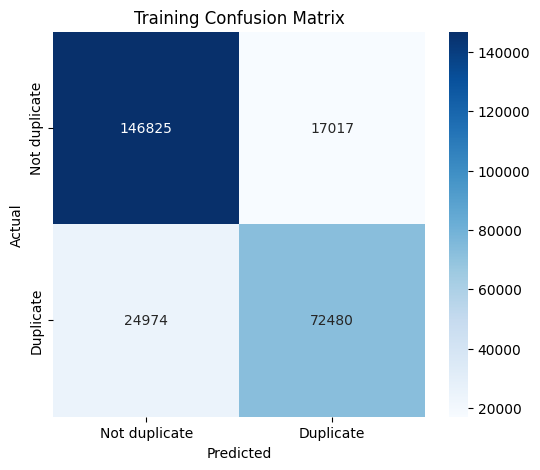


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.87    163842
           1       0.81      0.74      0.78     97454

    accuracy                           0.84    261296
   macro avg       0.83      0.82      0.83    261296
weighted avg       0.84      0.84      0.84    261296

Validation
Log Loss      : 0.4596
ROC-AUC       : 0.8423
F1-score      : 0.6323
Inference time: 0.1395 s


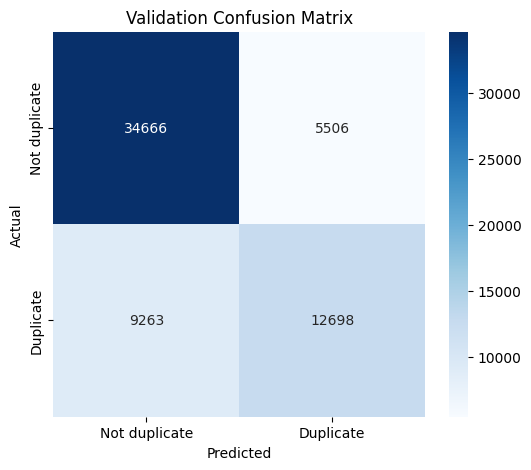


Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.86      0.82     40172
           1       0.70      0.58      0.63     21961

    accuracy                           0.76     62133
   macro avg       0.74      0.72      0.73     62133
weighted avg       0.76      0.76      0.76     62133



{'log_loss': 0.45960633206777646,
 'roc_auc': 0.84228143875466,
 'f1_score': 0.6322917963400971,
 'inference_time': 0.1395098000066355}

In [22]:
classify_analysis(y_train_sw_svd, X_train_sw_svd, xgb_sw_svd_model, 'Training')
classify_analysis(y_val_sw_svd, X_val_sw_svd, xgb_sw_svd_model, 'Validation')

#### Error Analysis

In [53]:
train_errors_sw_svd = error_analysis(train_df_sw_svd, X_train_sw_svd, xgb_sw_svd_model)

print("False Positive training examples")
display(train_errors_sw_svd["fp"].head())

print("False Negative training examples")
display(train_errors_sw_svd["fn"].head())

Error Analysis
TP : 72480
TN : 146825
FP : 17017
FN : 24974
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[which, be, the, best, place, to, reside, in, ...","[which, ia, the, best, place, to, visit, in, i...",7,0.538462,...,0.014441,0.086373,-0.045393,0.026737,0.024533,-0.005883,-0.012869,-0.015971,1,0.620615
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,"[how, do, i, download, free, movie, from, torr...","[how, do, i, download, from, torrent]",6,0.750000,...,-0.033029,-0.020804,0.049569,-0.034298,0.012469,0.023319,0.011773,0.001983,1,0.577399
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,"[which, language, do, you, think, be, the, mos...","[which, be, the, most, difficult, language, of...",7,0.466667,...,0.015119,-0.013738,-0.016487,0.008513,0.012628,0.048308,-0.020399,0.017289,1,0.689205
47,258350,258351,Why is making money online is difficult?,Is making money online real?,0,train,"[why, be, make, money, online, be, difficult]","[be, make, money, online, real]",4,0.571429,...,-0.048215,0.013518,0.001100,-0.007600,-0.009029,-0.010212,-0.014826,-0.005819,1,0.752994
49,432554,432555,What is the best book to read on investment st...,What are some good books on investment?,0,train,"[what, be, the, best, book, to, read, on, inve...","[what, be, some, good, book, on, investment]",5,0.416667,...,0.003540,-0.013259,0.013707,0.036649,-0.045539,0.008268,-0.024628,0.006970,1,0.629841


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
7,176809,185587,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,1,train,"[what, be, the, best, small, business, to, sta...","[which, business, startup, should, i, start, i...",5,0.263158,...,0.009370,0.019550,0.029969,-0.015859,-0.006786,0.007761,-0.003624,-0.007888,0,0.421740
21,237270,144610,What is the evolutionary explanation for the e...,What's the evolutionary reason for the hymen?,1,train,"[what, be, the, evolutionary, explanation, for...","[what, be, the, evolutionary, reason, for, the...",6,0.600000,...,0.005604,0.010498,-0.006164,-0.004525,0.008704,-0.015467,0.003252,-0.001434,0,0.391816
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,"[what, be, the, prerequisite, for, study, fini...","[what, be, the, mathematical, prerequisite, fo...",8,0.615385,...,-0.000160,0.000170,-0.003494,-0.002052,0.006993,0.000182,0.005842,-0.002597,0,0.341862
44,110587,110588,What is the conclusive proof of the existence ...,What are black holes? Do they really exist? Ho...,1,train,"[what, be, the, conclusive, proof, of, the, ex...","[what, be, black, hole, do, they, really, exis...",4,0.266667,...,0.041999,-0.004304,-0.041462,0.000700,-0.004876,-0.013145,0.004032,-0.015422,0,0.342794
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,"[how, be, the, master, of, data, science, prog...","[what, be, the, good, university, offer, data,...",9,0.428571,...,-0.018755,-0.019299,-0.012196,-0.010188,-0.011489,0.009456,0.016873,0.003065,0,0.159280


In [54]:
val_errors_sw_svd = error_analysis(val_df_sw_svd, X_val_sw_svd, xgb_sw_svd_model)

print("False Positive validation examples")
display(val_errors_sw_svd["fp"].head())

print("False Negative validation examples")
display(val_errors_sw_svd["fn"].head())

Error Analysis
TP : 12698
TN : 34666
FP : 5506
FN : 9263
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[when, do, you, join, quora]","[why, do, i, join, quora]",3,0.428571,...,0.003097,0.013836,-0.015454,-0.037914,0.007238,0.015433,-0.041416,0.019768,1,0.617828
34,262729,262730,Is it possible to see who last accessed or vie...,Possible to see who is watching you live on fa...,0,val,"[be, it, possible, to, see, who, last, access,...","[possible, to, see, who, be, watch, you, live,...",7,0.411765,...,-0.022563,-0.017226,-0.005854,0.026377,0.036729,0.019920,0.031122,0.016256,1,0.762990
48,30745,29667,Why do most café startups fail?,Why do so many startups fail?,0,val,"[why, do, most, café, startup, fail]","[why, do, so, many, startup, fail]",4,0.500000,...,-0.004580,0.027518,0.005300,-0.018345,-0.005241,-0.035619,0.029164,0.054170,1,0.597627
54,378046,378047,League of Legends: What should one know about ...,League of Legends: What should one know about ...,0,val,"[league, of, legend, what, should, one, know, ...","[league, of, legend, what, should, one, know, ...",11,0.733333,...,-0.001004,0.006507,-0.011837,-0.008914,0.038228,0.008173,-0.001123,0.010454,1,0.748547
61,254415,254416,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0,val,"[can, magnetic, field, ever, do, work, if, not...","[if, magnetic, field, cannot, do, work, how, c...",10,0.625000,...,-0.011823,-0.009336,-0.018439,0.027708,-0.004407,-0.026604,-0.011717,0.012001,1,0.526504


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"[what, be, the, sahara, and, how, do, the, ave...","[what, be, the, sahara, and, how, do, the, ave...",14,0.823529,...,0.007419,0.047614,-0.007636,0.039346,-0.003118,-0.025965,0.021623,-0.007125,0,0.153829
3,26893,83712,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1,val,"[when, be, it, too, late, to, learn, piano]","[be, it, too, late, to, learn, to, play, the, ...",7,0.583333,...,-0.000789,0.001780,-0.002749,-0.003043,0.014790,-0.010714,-0.001687,0.024697,0,0.493624
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,"[can, i, use, this, number, 1800, 251, 4919, b...","[what, be, belkin, router, tech, support, s, p...",5,0.294118,...,0.019146,0.005553,-0.026382,0.035009,0.039989,-0.062655,0.034065,0.049156,0,0.323101
12,360478,202804,How do I find best online sites for watching T...,What websites do you use to watch TV shows?,1,val,"[how, do, i, find, best, online, site, for, wa...","[what, websites, do, you, use, to, watch, tv, ...",4,0.250000,...,-0.008878,-0.008083,-0.020130,-0.006706,-0.006830,0.001488,-0.007950,-0.017717,0,0.270379
18,179589,219828,Which is best choice for newbies Honda hornet ...,I am looking to buy new bike. Suzuki gixxer 15...,1,val,"[which, be, best, choice, for, newbie, honda, ...","[i, be, look, to, buy, new, bike, suzuki, gixx...",9,0.450000,...,-0.005772,0.006573,-0.028800,-0.004811,-0.014343,0.013533,-0.014084,-0.000556,0,0.355813


## Without stopwords

### Data Loading

In [24]:
train_df_nosw_svd = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_nosw_tf_idf_svd.parquet")
val_df_nosw_svd = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_nosw_tf_idf_svd.parquet")

train_df_nosw_svd.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_90,q2_svd_91,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,"[practical, management, strategic, management]","[practical, aspect, strategic, management]",3,0.750000,...,0.001743,-0.000522,-0.001499,-0.001979,0.002011,-0.002562,-0.001081,-0.000625,0.002287,0.003682
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,"[useful, makeuseof, answer]","[q, site, yahoo, answer, hate, speech, allow]",1,0.111111,...,0.008866,0.027980,0.005359,-0.007625,0.000451,-0.004390,-0.029462,0.008413,-0.012811,-0.004550
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,"[best, place, reside, india]","[ia, best, place, visit, india]",3,0.500000,...,0.001344,-0.006568,0.007986,0.014433,-0.022673,0.018463,0.014379,-0.005300,0.004824,-0.020186


### Design matrix and target

In [25]:
X_train_nosw_svd = train_df_nosw_svd.drop(columns=DROP_COLUMNS)
X_val_nosw_svd = val_df_nosw_svd.drop(columns=DROP_COLUMNS)

X_train_nosw_svd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261296 entries, 0 to 261295
Columns: 206 entries, common_word_count to q2_svd_99
dtypes: float64(203), int64(3)
memory usage: 410.7 MB


In [26]:
y_train_nosw_svd = train_df_nosw_svd['is_duplicate']
y_val_nosw_svd = val_df_nosw_svd['is_duplicate']

y_train_nosw_svd.info()

<class 'pandas.core.series.Series'>
RangeIndex: 261296 entries, 0 to 261295
Series name: is_duplicate
Non-Null Count   Dtype
--------------   -----
261296 non-null  int64
dtypes: int64(1)
memory usage: 2.0 MB


### Basic Model

In [27]:
xgb_nosw_svd_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

In [29]:
train_model(xgb_nosw_svd_model, X_train_nosw_svd, y_train_nosw_svd)

Training time: 19.17 seconds


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 19.172397900023498)

#### Evaluation

Training
Log Loss      : 0.3540
ROC-AUC       : 0.9216
F1-score      : 0.7791
Inference time: 0.3510 s


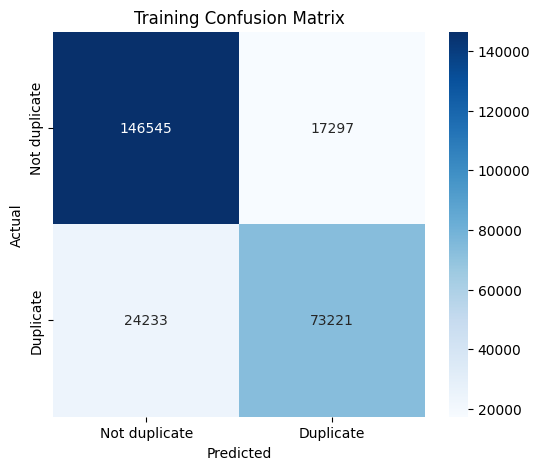


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.89      0.88    163842
           1       0.81      0.75      0.78     97454

    accuracy                           0.84    261296
   macro avg       0.83      0.82      0.83    261296
weighted avg       0.84      0.84      0.84    261296

Validation
Log Loss      : 0.4595
ROC-AUC       : 0.8434
F1-score      : 0.6282
Inference time: 0.1369 s


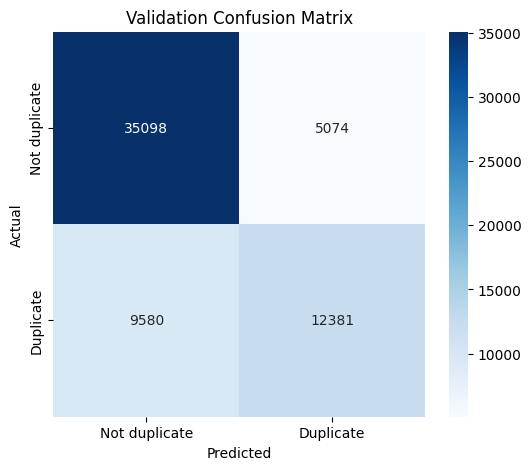


Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.87      0.83     40172
           1       0.71      0.56      0.63     21961

    accuracy                           0.76     62133
   macro avg       0.75      0.72      0.73     62133
weighted avg       0.76      0.76      0.76     62133



{'log_loss': 0.459514970733701,
 'roc_auc': 0.8434093700580062,
 'f1_score': 0.6282220418104323,
 'inference_time': 0.13691910007037222}

In [30]:
classify_analysis(y_train_nosw_svd, X_train_nosw_svd, xgb_nosw_svd_model, 'Training')
classify_analysis(y_val_nosw_svd, X_val_nosw_svd, xgb_nosw_svd_model, 'Validation')

#### Error analysis

In [55]:
train_errors_nosw_svd = error_analysis(train_df_nosw_svd, X_train_nosw_svd, xgb_nosw_svd_model)

print("False Positive training examples")
display(train_errors_nosw_svd["fp"].head())

print("False Negative training examples")
display(train_errors_nosw_svd["fn"].head())

Error Analysis
TP : 73221
TN : 146545
FP : 17297
FN : 24233
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
5,425388,425389,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0,train,"[people, avoid, south, facing, home]","[south, facing, home, important, people]",4,0.666667,...,-0.019736,0.082972,0.002719,0.022946,0.035689,-0.032038,0.016173,0.078623,1,0.512974
10,531572,531573,"If an answer has been collapsed, and then impr...",Why did Quora collapse my answer on ISIS and 911?,0,train,"[answer, collapse, improve, uncollapsed, colla...","[quora, collapse, answer, isi, 911]",3,0.333333,...,-0.007638,-0.014250,0.004112,-0.004073,-0.000258,0.001374,-0.006857,0.003221,1,0.643876
28,450836,450837,How does a college speech class work?,Why are speech classes in college useful or im...,0,train,"[college, speech, class, work]","[speech, class, college, useful, important]",3,0.500000,...,0.011671,0.070385,-0.009211,-0.001128,0.026572,0.002347,0.012643,0.033704,1,0.503610
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,"[language, think, difficult, world]","[difficult, language, world]",3,0.750000,...,-0.009371,0.003593,-0.003044,-0.018806,-0.024298,-0.044513,-0.013801,-0.018147,1,0.718164
47,258350,258351,Why is making money online is difficult?,Is making money online real?,0,train,"[make, money, online, difficult]","[make, money, online, real]",3,0.600000,...,-0.012294,0.018597,-0.018384,0.003367,0.000422,-0.011512,-0.017727,0.005798,1,0.775556


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,"[prerequisite, study, finite, element, method,...","[mathematical, prerequisite, understand, finit...",4,0.500000,...,0.002104,-0.000652,0.001715,0.000909,-0.001758,0.000428,0.001865,-0.000083,0,0.374962
46,133666,23320,Are bicarbonate of soda and baking soda the same?,Is Baking Soda and Bicarbonate Soda the same?,1,train,"[bicarbonate, soda, baking, soda]","[bake, soda, bicarbonate, soda]",2,0.500000,...,0.000495,0.000417,-0.000066,0.000391,-0.000336,-0.000832,0.001232,0.001748,0,0.294948
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,"[master, data, science, program, like, monash,...","[good, university, offer, data, science, maste...",5,0.357143,...,-0.025755,0.032729,0.006514,-0.023962,0.030527,0.041155,-0.055492,-0.024690,0,0.189121
65,31773,6887,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,1,train,"[ex, leave, say, love, still, talk, get, back]","[get, ex, boyfriend, back]",3,0.333333,...,-0.007553,0.018018,0.007761,0.002258,0.001277,0.005409,0.003521,-0.003667,0,0.371525
147,201286,112903,Are there any people living in india who have ...,Has anybody visited all the countries in the w...,1,train,"[people, live, india, visit, country, world]","[anybody, visit, country, world, possible, man...",4,0.333333,...,0.007925,0.010476,0.112670,0.026079,0.003076,0.005910,-0.068503,0.013665,0,0.476741


In [56]:
val_errors_nosw_svd = error_analysis(val_df_nosw_svd, X_val_nosw_svd, xgb_nosw_svd_model)

print("False Positive validation examples")
display(val_errors_nosw_svd["fp"].head())

print("False Negative validation examples")
display(val_errors_nosw_svd["fn"].head())

Error Analysis
TP : 12381
TN : 35098
FP : 5074
FN : 9580
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
4,353543,353544,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0,val,"[xy, chromosome, change, xx, one]","[xx, xy, chromosome, different]",3,0.500000,...,0.007219,0.005502,0.010816,0.010093,-0.016116,0.004892,-0.005416,0.015108,1,0.540261
5,45508,303505,When did you join Quora?,Why did I join Quora?,0,val,"[join, quora]","[join, quora]",2,1.000000,...,-0.007151,0.002569,0.011842,0.009164,-0.007357,-0.010986,0.006346,0.012783,1,0.769796
8,54140,299231,Which is best software course for a fresher to...,What are the best courses to get a good job in...,0,val,"[best, software, course, fresher, get, job, co...","[best, course, get, good, job, software]",5,0.555556,...,0.008030,-0.012557,0.000859,0.002623,0.035662,0.007787,-0.006125,0.029641,1,0.663936
28,94017,316021,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0,val,"[cause, itchy, scalp, without, dandruff]","[cause, itchy, scalp, dandruff]",4,0.800000,...,0.005934,-0.002452,-0.003304,0.000580,0.003311,0.004186,0.002009,-0.000946,1,0.701761
61,254415,254416,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0,val,"[magnetic, field, ever, work, one, magnet, lif...","[magnetic, field, cannot, work, one, magnet, p...",6,0.545455,...,-0.014866,0.003757,0.011309,-0.006901,0.007698,0.001419,-0.001818,0.005798,1,0.642995


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_tokens,question2_tokens,common_word_count,jaccard,...,q2_svd_92,q2_svd_93,q2_svd_94,q2_svd_95,q2_svd_96,q2_svd_97,q2_svd_98,q2_svd_99,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,"[open, ppf, account, benefit]","[ppf, account]",2,0.500000,...,-0.034392,-0.017973,-0.031665,-0.000788,-0.011230,0.012562,0.041063,-0.000940,0,0.300215
12,360478,202804,How do I find best online sites for watching T...,What websites do you use to watch TV shows?,1,val,"[find, best, online, site, watch, tv, show]","[websites, use, watch, tv, show]",3,0.333333,...,0.064799,-0.048460,-0.035845,0.011329,0.005134,-0.020266,0.043066,0.006851,0,0.266504
18,179589,219828,Which is best choice for newbies Honda hornet ...,I am looking to buy new bike. Suzuki gixxer 15...,1,val,"[best, choice, newbie, honda, hornet, 160r, su...","[look, buy, new, bike, suzuki, gixxer, 155, ho...",6,0.428571,...,0.011413,-0.017814,-0.006280,0.028850,-0.020057,-0.011868,-0.002157,0.014681,0,0.280181
21,1894,23107,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,1,val,"[saltwater, taffy, candy, import, austria]","[saltwater, taffy, candy, import, mongolia]",4,0.666667,...,-0.000043,-0.000055,0.001394,-0.000121,-0.000510,-0.000059,-0.000134,0.000711,0,0.205290
24,247714,394432,"Are there any free online resources (courses, ...",Where can I do an online business analyst cert...,1,val,"[free, online, resource, course, videos, liter...","[online, business, analyst, certification, free]",4,0.363636,...,-0.006756,-0.049224,0.033354,-0.030750,-0.054529,0.020549,-0.013305,0.002404,0,0.245770


# Sentence Embeddings

## Sentence Embeddings - Model 1 ("all-mpnet-base-v2")

### Data Loading

In [3]:
train_df_se1 = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_se1.parquet")
val_df_se1 = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_se1.parquet")

train_df_se1.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0.828576,0.585532
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0.061228,1.370235
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0.729282,0.735823


In [4]:
train_emb_q1_se1 = np.load(f"{PROCESS_DATA_PATH}/embedding_se1_train_q1.npy")
train_emb_q2_se1 = np.load(f"{PROCESS_DATA_PATH}/embedding_se1_train_q2.npy")

val_emb_q1_se1 = np.load(f"{PROCESS_DATA_PATH}/embedding_se1_val_q1.npy")
val_emb_q2_se1 = np.load(f"{PROCESS_DATA_PATH}/embedding_se1_val_q2.npy")

### Design matrix and target

In [5]:
X_train_emb_se1 = np.hstack([train_emb_q1_se1, train_emb_q2_se1])
X_val_emb_se1 = np.hstack([val_emb_q1_se1, val_emb_q2_se1])

In [6]:
X_train_se1 = np.hstack([X_train_emb_se1, train_df_se1[EMBEDDING_FEATURES].to_numpy()])
X_val_se1 = np.hstack([X_val_emb_se1, val_df_se1[EMBEDDING_FEATURES].to_numpy()])

In [7]:
y_train_se_1 = train_df_se1["is_duplicate"].values
y_val_se_1  = val_df_se1["is_duplicate"].values

### Basic Model

In [38]:
xgb_se1_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

In [39]:
train_model(xgb_se1_model, X_train_se1, y_train_se_1)

Training time: 158.48 seconds


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 158.47535490000155)

#### Evaluation

Training
Log Loss      : 0.2083
ROC-AUC       : 0.9773
F1-score      : 0.8936
Inference time: 0.6843 s


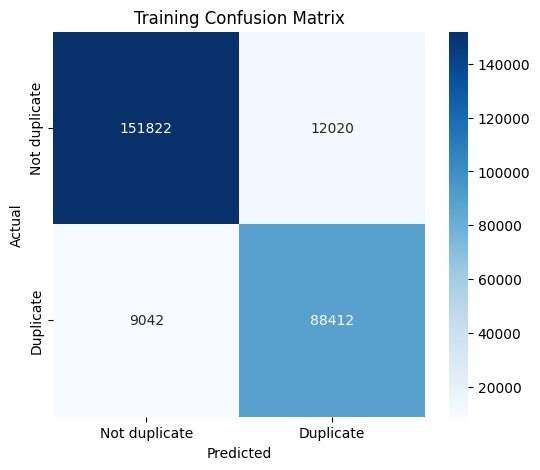


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.93      0.94    163842
           1       0.88      0.91      0.89     97454

    accuracy                           0.92    261296
   macro avg       0.91      0.92      0.91    261296
weighted avg       0.92      0.92      0.92    261296

Validation
Log Loss      : 0.3264
ROC-AUC       : 0.9266
F1-score      : 0.7749
Inference time: 0.1988 s


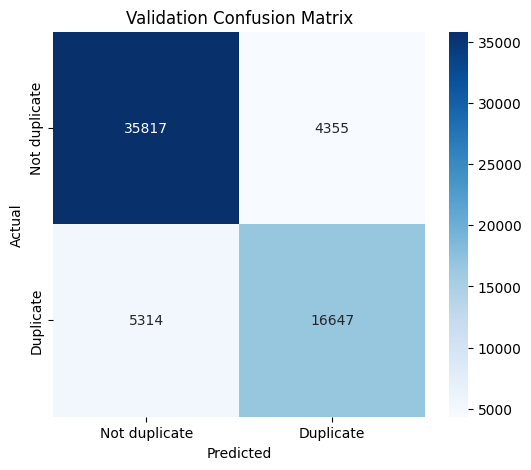


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     40172
           1       0.79      0.76      0.77     21961

    accuracy                           0.84     62133
   macro avg       0.83      0.82      0.83     62133
weighted avg       0.84      0.84      0.84     62133



{'log_loss': 0.3263880863910671,
 'roc_auc': 0.9265749950863578,
 'f1_score': 0.7749458836673416,
 'inference_time': 0.19877669995184988}

In [40]:
classify_analysis(y_train_se_1, X_train_se1, xgb_se1_model, 'Training')
classify_analysis(y_val_se_1, X_val_se1, xgb_se1_model, 'Validation')

#### Error analysis

In [57]:
train_errors_se1 = error_analysis(train_df_se1, X_train_se1, xgb_se1_model)

print("False Positive training examples")
display(train_errors_se1["fp"].head())

print("False Negative training examples")
display(train_errors_se1["fn"].head())

Error Analysis
TP : 88412
TN : 151822
FP : 12020
FN : 9042
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
9,181645,181646,Who do you think is the best singer that has e...,Who is the best singer of all time?,0,train,Who do you think is the best singer that has e...,Who is the best singer of all time?,0.870859,0.508215,1,0.666526
20,197537,65750,How do I download free movies from torrent?,How do I download from torrent?,0,train,How do I download free movies from torrent?,How do I download from torrent?,0.829496,0.583959,1,0.515009
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0.942690,0.338555,1,0.684335
57,454738,454739,How do I copy pictures on icloud to Facebook?,How can I transfer Facebook pictures to iCloud?,0,train,How do I copy pictures on icloud to Facebook?,How can I transfer Facebook pictures to iCloud?,0.935074,0.360350,1,0.623732
83,72064,72065,Did India won a single medal in Rio Olympics 2...,How many medals did India won in Olympic 2016?,0,train,Did India won a single medal in Rio Olympics 2...,How many medals did India won in Olympic 2016?,0.842786,0.560740,1,0.676230


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
7,176809,185587,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,1,train,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,0.886132,0.477216,0,0.470247
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,How is the master of data science program like...,What are the good universities offering data s...,0.684569,0.794268,0,0.216710
65,31773,6887,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,1,train,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,0.534478,0.964906,0,0.236316
82,299018,383486,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,1,train,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,0.783701,0.657722,0,0.325163
96,2205,2206,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,1,train,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,0.615937,0.876429,0,0.166170


In [59]:
val_errors_se1 = error_analysis(val_df_se1, X_val_se1, xgb_se1_model)

print("False Positive validation examples")
display(val_errors_se1["fp"].head())

print("False Negative validation examples")
display(val_errors_se1["fn"].head())

Error Analysis
TP : 16647
TN : 35817
FP : 4355
FN : 5314
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
28,94017,316021,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0,val,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0.926739,0.382782,1,0.667038
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0.943215,0.337001,1,0.828893
61,254415,254416,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0,val,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0.905712,0.434252,1,0.706081
86,58250,58251,Do anyone know about the Lenovo Ideapad 500S l...,How is Lenovo Ideapad 500s(14) laptop?,0,val,Do anyone know about the Lenovo Ideapad 500S l...,How is Lenovo Ideapad 500s(14) laptop?,0.815718,0.607095,1,0.521337
97,167896,167897,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0,val,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0.814209,0.609575,1,0.716294


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,0.813441,0.610834,0,0.329230
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0.869866,0.510165,0,0.339965
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,0.777924,0.666447,0,0.291648
17,68233,102257,Which is the best way of living life?,What are some of the best examples of how to l...,1,val,Which is the best way of living life?,What are some of the best examples of how to l...,0.672122,0.809788,0,0.337064
21,1894,23107,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,1,val,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,0.874898,0.500204,0,0.436167


### Model Using Optimal Hyper Parameters

In [8]:
space = {
    "max_depth": hp.choice("max_depth", [5, 6, 7]),
    "learning_rate": hp.uniform("learning_rate", 0.07, 0.13),
    "n_estimators": hp.choice("n_estimators", [250, 300, 350]),
    "min_child_weight": hp.choice("min_child_weight", [1, 2, 3]),
    "subsample": hp.uniform("subsample", 0.8, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.8, 1.0),
    "gamma": hp.uniform("gamma", 0, 1),
    "reg_alpha": hp.loguniform("reg_alpha", np.log(1e-4), np.log(0.5)),
    "reg_lambda": hp.uniform("reg_lambda", 1, 5)
}

In [12]:
cv = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [13]:
def objective(params, X_train, y_train):

    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            #device="cuda",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params
        )

        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]

        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]

        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)

        scores.append(f1_score(y_val, preds))

    return {
        "loss": -np.mean(scores),
        "status": STATUS_OK
    }

In [14]:
trials_se1 = Trials()

best_se1 = fmin(
    fn=lambda params: objective(params, X_train_se1, y_train_se_1),
    space=space,
    algo=tpe.suggest,
    max_evals=8,
    trials=trials_se1,
    rstate=np.random.default_rng(RANDOM_STATE)
)

100%|██████████| 8/8 [41:35<00:00, 311.99s/trial, best loss: -0.8403566391330071]


In [15]:
best_params_se1 = space_eval(space, best_se1)

print(best_params_se1)

{'colsample_bytree': 0.8010976066509657, 'gamma': 0.8848819741254269, 'learning_rate': 0.0747389967901448, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 350, 'reg_alpha': 0.15295230577607952, 'reg_lambda': 3.4329966486845462, 'subsample': 0.8600842709581017}


In [16]:
best_model_se1 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    #device="cuda",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params_se1
)

best_model_se1.fit(X_train_se1, y_train_se_1)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8010976066509657
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [17]:
joblib.dump(best_model_se1, f"{MODEL_PATH}/xgboost_tfidf_se1.joblib")

['models/xgboost_tfidf_se1.joblib']

#### Evaluation

Training
Log Loss      : 0.1817
ROC-AUC       : 0.9856
F1-score      : 0.9168
Inference time: 0.8164 s


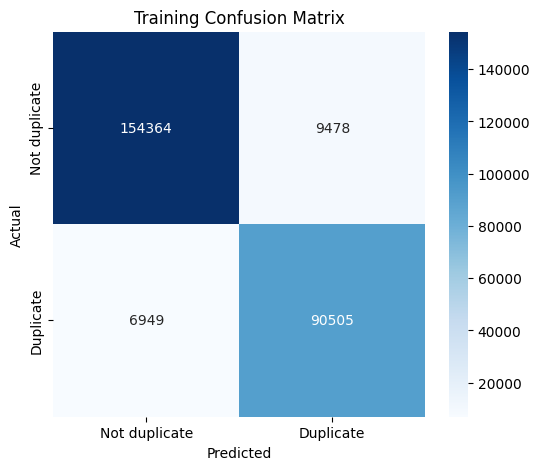


Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95    163842
           1       0.91      0.93      0.92     97454

    accuracy                           0.94    261296
   macro avg       0.93      0.94      0.93    261296
weighted avg       0.94      0.94      0.94    261296

Validation
Log Loss      : 0.3264
ROC-AUC       : 0.9271
F1-score      : 0.7741
Inference time: 0.3325 s


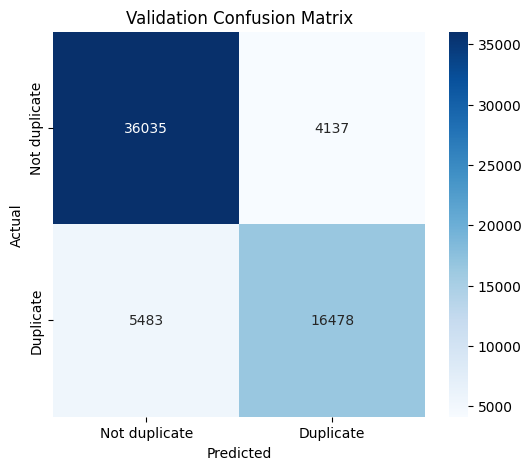


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.90      0.88     40172
           1       0.80      0.75      0.77     21961

    accuracy                           0.85     62133
   macro avg       0.83      0.82      0.83     62133
weighted avg       0.84      0.85      0.84     62133



{'log_loss': 0.3264201521556593,
 'roc_auc': 0.9271368952038178,
 'f1_score': 0.7740511086057873,
 'inference_time': 0.3325058000627905}

In [18]:
classify_analysis(y_train_se_1, X_train_se1, best_model_se1, 'Training')
classify_analysis(y_val_se_1, X_val_se1, best_model_se1, 'Validation')

#### Error analysis

In [19]:
train_errors_se1 = error_analysis(train_df_se1, X_train_se1, best_model_se1)

print("False Positive training examples")
display(train_errors_se1["fp"].head())

print("False Negative training examples")
display(train_errors_se1["fn"].head())

Error Analysis
TP : 90505
TN : 154364
FP : 9478
FN : 6949
False Positive training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0.942690,0.338555,1,0.646799
57,454738,454739,How do I copy pictures on icloud to Facebook?,How can I transfer Facebook pictures to iCloud?,0,train,How do I copy pictures on icloud to Facebook?,How can I transfer Facebook pictures to iCloud?,0.935074,0.360350,1,0.571791
83,72064,72065,Did India won a single medal in Rio Olympics 2...,How many medals did India won in Olympic 2016?,0,train,Did India won a single medal in Rio Olympics 2...,How many medals did India won in Olympic 2016?,0.842786,0.560740,1,0.550812
116,491553,293811,How do AB positive and B negative blood types ...,How do AB positive and A negative blood types ...,0,train,How do AB positive and B negative blood types ...,How do AB positive and A negative blood types ...,0.962806,0.272742,1,0.637057
153,511558,511559,Why is reddit not blocked in China?,Why isn't Quora blocked in China?,0,train,Why is reddit not blocked in China?,Why isn't Quora blocked in China?,0.881601,0.486620,1,0.510375


False Negative training examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,How is the master of data science program like...,What are the good universities offering data s...,0.684569,0.794268,0,0.113033
65,31773,6887,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,1,train,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,0.534478,0.964906,0,0.280307
82,299018,383486,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,1,train,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,0.783701,0.657722,0,0.458857
96,2205,2206,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,1,train,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,0.615937,0.876429,0,0.451604
112,92895,288588,Which is best IIT in India?,Which IIT campus is the best?,1,train,Which is best IIT in India?,Which IIT campus is the best?,0.857720,0.533442,0,0.458416


In [20]:
val_errors_se1 = error_analysis(val_df_se1, X_val_se1, best_model_se1)

print("False Positive validation examples")
display(val_errors_se1["fp"].head())

print("False Negative validation examples")
display(val_errors_se1["fn"].head())

Error Analysis
TP : 16478
TN : 36035
FP : 4137
FN : 5483
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
28,94017,316021,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0,val,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0.926739,0.382782,1,0.736326
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0.943215,0.337001,1,0.705227
61,254415,254416,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0,val,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0.905712,0.434252,1,0.747803
86,58250,58251,Do anyone know about the Lenovo Ideapad 500S l...,How is Lenovo Ideapad 500s(14) laptop?,0,val,Do anyone know about the Lenovo Ideapad 500S l...,How is Lenovo Ideapad 500s(14) laptop?,0.815718,0.607095,1,0.642729
97,167896,167897,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0,val,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0.814209,0.609575,1,0.694512


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,0.813441,0.610834,0,0.272882
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0.869866,0.510165,0,0.301478
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,0.777924,0.666447,0,0.297623
17,68233,102257,Which is the best way of living life?,What are some of the best examples of how to l...,1,val,Which is the best way of living life?,What are some of the best examples of how to l...,0.672122,0.809788,0,0.334474
21,1894,23107,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,1,val,Why is saltwater taffy candy imported in Austria?,Why is Saltwater taffy candy imported in Mongo...,0.874898,0.500204,0,0.414193


## Sentence Embeddings - Model 2 ("BAAI/bge-base-en-v1.5")

### Data Loading

In [41]:
train_df_se2 = pd.read_parquet(f"{PROCESS_DATA_PATH}/train_df_se2.parquet")
val_df_se2 = pd.read_parquet(f"{PROCESS_DATA_PATH}/val_df_se2.parquet")

train_df_se2.head(3)

,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean
0,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,train,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0.856630,0.535481
1,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,train,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0.518023,0.981811
2,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,train,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0.727708,0.737960


In [42]:
train_emb_q1_se2 = np.load(f"{PROCESS_DATA_PATH}/embedding_se2_train_q1.npy")
train_emb_q2_se2 = np.load(f"{PROCESS_DATA_PATH}/embedding_se2_train_q2.npy")

val_emb_q1_se2 = np.load(f"{PROCESS_DATA_PATH}/embedding_se2_val_q1.npy")
val_emb_q2_se2 = np.load(f"{PROCESS_DATA_PATH}/embedding_se2_val_q2.npy")

### Design matrix and target

In [43]:
X_train_emb_se2 = np.hstack([train_emb_q1_se2, train_emb_q2_se2])
X_val_emb_se2 = np.hstack([val_emb_q1_se2, val_emb_q2_se2])

In [44]:
X_train_se2 = np.hstack([X_train_emb_se2, train_df_se2[EMBEDDING_FEATURES].to_numpy()])
X_val_se2 = np.hstack([X_val_emb_se2, val_df_se2[EMBEDDING_FEATURES].to_numpy()])

In [45]:
y_train_se_2 = train_df_se2["is_duplicate"].values
y_val_se_2  = val_df_se2["is_duplicate"].values

### Basic Model

In [46]:
xgb_se2_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

In [47]:
train_model(xgb_se2_model, X_train_se2, y_train_se_2)

Training time: 169.15 seconds


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 169.14988230005838)

#### Evaluation

Training
Log Loss      : 0.2221
ROC-AUC       : 0.9747
F1-score      : 0.8871
Inference time: 0.7424 s


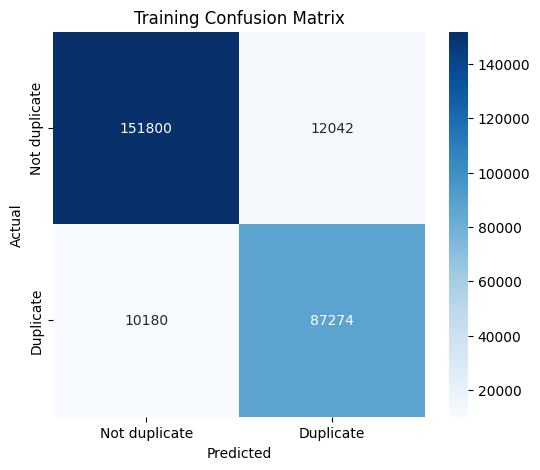


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.93      0.93    163842
           1       0.88      0.90      0.89     97454

    accuracy                           0.91    261296
   macro avg       0.91      0.91      0.91    261296
weighted avg       0.92      0.91      0.92    261296

Validation
Log Loss      : 0.3488
ROC-AUC       : 0.9159
F1-score      : 0.7516
Inference time: 0.1978 s


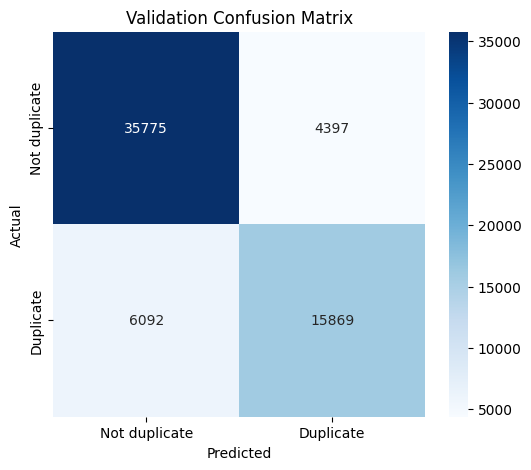


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87     40172
           1       0.78      0.72      0.75     21961

    accuracy                           0.83     62133
   macro avg       0.82      0.81      0.81     62133
weighted avg       0.83      0.83      0.83     62133



{'log_loss': 0.34875305434888715,
 'roc_auc': 0.9159173684616465,
 'f1_score': 0.7516044237099486,
 'inference_time': 0.19779849995393306}

In [48]:
classify_analysis(y_train_se_2, X_train_se2, xgb_se2_model, 'Training')
classify_analysis(y_val_se_2, X_val_se2, xgb_se2_model, 'Validation')

#### Error analysis

In [60]:
train_errors_se2 = error_analysis(train_df_se2, X_train_se2, xgb_se2_model)

print("False Positive validation examples")
display(train_errors_se2["fp"].head())

print("False Negative validation examples")
display(train_errors_se2["fn"].head())

Error Analysis
TP : 87274
TN : 151800
FP : 12042
FN : 10180
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
38,150637,235318,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0,train,Which language do you think is the most diffic...,Which is the most difficult language of the wo...,0.927325,0.381247,1,0.790773
53,243093,261858,How can I get a six pack and how long would it...,How long would it take to get six packs?,0,train,How can I get a six pack and how long would it...,How long would it take to get six packs?,0.942280,0.339765,1,0.590957
57,454738,454739,How do I copy pictures on icloud to Facebook?,How can I transfer Facebook pictures to iCloud?,0,train,How do I copy pictures on icloud to Facebook?,How can I transfer Facebook pictures to iCloud?,0.950845,0.313544,1,0.653848
106,28858,343001,Do atheists believe in ghosts?,Do theists believe in ghosts?,0,train,Do atheists believe in ghosts?,Do theists believe in ghosts?,0.909476,0.425497,1,0.541610
116,491553,293811,How do AB positive and B negative blood types ...,How do AB positive and A negative blood types ...,0,train,How do AB positive and B negative blood types ...,How do AB positive and A negative blood types ...,0.972884,0.232878,1,0.525703


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
31,114980,114981,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,1,train,What are the prerequisites for studying Finite...,What are the mathematical prerequisites for un...,0.882827,0.484094,0,0.251633
60,421632,421633,How is the master of data science program like...,What are the good universities offering data s...,1,train,How is the master of data science program like...,What are the good universities offering data s...,0.818853,0.601909,0,0.192586
65,31773,6887,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,1,train,My ex has just left me she said she doesn't lo...,How do I get my ex boyfriend back?,0.728949,0.736276,0,0.225768
82,299018,383486,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,1,train,What can be the best Valentine's Day gift?,What are some good Valentine's Day gifts for h...,0.802834,0.627959,0,0.417060
96,2205,2206,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,1,train,Can I do meditation all day long? Does it help...,Does meditation really help in controlling tho...,0.690347,0.786959,0,0.292132


In [61]:
val_errors_se2 = error_analysis(val_df_se2, X_val_se2, xgb_se2_model)

print("False Positive validation examples")
display(val_errors_se2["fp"].head())

print("False Negative validation examples")
display(val_errors_se2["fn"].head())

Error Analysis
TP : 15869
TN : 35775
FP : 4397
FN : 6092
False Positive validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
28,94017,316021,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0,val,What causes an itchy scalp without dandruff?,What are the causes of an itchy scalp and dand...,0.922438,0.393858,1,0.518819
43,483191,225770,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0,val,What is it like to live on an Israeli settlement?,What is it like to live in an Israeli settleme...,0.950732,0.313904,1,0.846910
61,254415,254416,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0,val,"Can magnetic fields ever do work? If not, how ...","If magnetic fields can't do work, how can one ...",0.905137,0.435576,1,0.676607
97,167896,167897,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0,val,"Why does Obama always call Donald Trump ""The D...",Why is Donald Trump called 'The Donald'?,0.860249,0.528680,1,0.857580
133,106728,106729,Would it be advisable to purchase a Macbook Ai...,How much better will the Macbook Air 2016 be c...,0,val,Would it be advisable to purchase a Macbook Ai...,How much better will the Macbook Air 2016 be c...,0.849218,0.549149,1,0.563645


False Negative validation examples


,qid1,qid2,question1,question2,is_duplicate,split,question1_clean,question2_clean,embedding_cosine,embedding_euclidean,prediction,probability
1,70709,109144,How can I open a PPF account? And what are its...,What is PPF account?,1,val,How can I open a PPF account? And what are its...,What is PPF account?,0.869970,0.509960,0,0.367035
2,6421,68425,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1,val,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",0.857184,0.534445,0,0.208585
7,33502,31173,How do I get my picture to be different on Quora?,How do I use my picture as my profile picture ...,1,val,How do I get my picture to be different on Quora?,How do I use my picture as my profile picture ...,0.818979,0.601699,0,0.418132
11,306530,94950,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,1,val,Can I use this number //* [[1800*251*4919]] */...,What is Belkin Router tech support's phone num...,0.851798,0.544430,0,0.357384
17,68233,102257,Which is the best way of living life?,What are some of the best examples of how to l...,1,val,Which is the best way of living life?,What are some of the best examples of how to l...,0.736357,0.726144,0,0.214841


**Observation:**
- Feature quality ranking matches Logistic Regression: raw TF-IDF is more than TF-IDF + SVD but sentence embeddings is the best.
- Untuned XGBoost underperforms noticeably on raw/SVD TF-IDF (val F1 as low as ~0.32), much more than Logistic Regression does on the same features — tree-based splits don't exploit high-dimensional sparse TF-IDF well without tuning.
- Hyperopt tuning (TPE, StratifiedKFold CV) on the Sentence Embeddings Model 1 ("all-mpnet-base-v2") feature set gives the best Log Loss/ROC-AUC of any model in the project — this configuration (`models/xgboost_tfidf_se1.joblib`) is the one selected for production deployment.
